# 02 — Qualifying Pace vs Race Pace: What Does the Game's "Pace" Attribute Actually Track?

Notebook 01 compared the blended `overall` rating (and its four sub-attributes) against
**season points and championship position** — a race-day, points-scoring outcome. It didn't
separate two conceptually different things that F1 fans (and the game) distinguish:

- **Qualifying pace**: a single fast lap, car and driver at their most extreme, no traffic,
  no tire degradation, no race strategy. This is what "Pace" as a driver attribute plausibly
  should track if it means raw one-lap speed.
- **Race pace / racecraft**: managing tires, traffic, strategy, and overtaking across a full
  grand prix distance — a different skill set, which is presumably closer to what the game's
  "Racecraft" attribute is meant to capture.

This notebook pulls **qualifying results** and **race results (with grid position)** from
Jolpica-F1, separately from the season-standings pull notebook 01 used, via the new
`scripts/fetch_qualifying_and_race_results.py`. It asks two questions:

1. Does **Pace** correlate more strongly with qualifying performance (avg qualifying position)
   or with race performance (avg points per race)?
2. Does **Racecraft** correlate specifically with **positions gained during races**
   (finish position vs. starting grid position) — a race-day overtaking metric that isn't
   just "did they have a fast car," rather than with pure qualifying pace?

As with notebook 01: n is ~19–22 drivers. Every result here is descriptive, not inferential —
p-values are reported for context, not as proof of anything at this sample size.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append(os.path.join(os.getcwd(), "..", "scripts"))
from build_dataset import last_name  # reuse the same normalized-last-name join key as notebook 01 / build_dataset.py

RAW_DIR = os.path.join("..", "data", "raw")
PROC_DIR = os.path.join("..", "data", "processed")

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

## Load ratings + per-round qualifying/race data

`data/processed/f1_ratings_vs_results.csv` (built by `build_dataset.py`) already has the
22-driver rating table joined to *season-end* standings. Here we additionally load the new
per-round CSVs and aggregate them to one row per driver per season:

- **Qualifying**: mean qualifying position, best qualifying position, number of qualifying
  sessions.
- **Race**: mean finish position, mean points per race (not season total, so partial-season
  2026 is comparable per-race to full-season 2025), mean positions gained
  (`grid - finish position`, positive = gained places), number of races.

In [2]:
ratings = pd.read_csv(os.path.join(PROC_DIR, "f1_ratings_vs_results.csv"))
ratings["name_key"] = ratings["driver"].map(last_name)

quali_all = pd.read_csv(os.path.join(RAW_DIR, "f1_qualifying_results.csv"))
race_all = pd.read_csv(os.path.join(RAW_DIR, "f1_race_results.csv"))


def quali_summary(season):
    df = quali_all[quali_all["season"] == season].copy()
    df["name_key"] = df["family_name"].map(last_name)
    return (
        df.groupby("name_key")
        .agg(
            avg_quali_position=("quali_position", "mean"),
            best_quali_position=("quali_position", "min"),
            n_quali=("quali_position", "count"),
        )
        .reset_index()
    )


def race_summary(season):
    df = race_all[race_all["season"] == season].copy()
    df["name_key"] = df["family_name"].map(last_name)
    df["positions_gained"] = df["grid"] - df["position"]
    return (
        df.groupby("name_key")
        .agg(
            avg_finish_position=("position", "mean"),
            avg_points_per_race=("points", "mean"),
            avg_positions_gained=("positions_gained", "mean"),
            avg_grid=("grid", "mean"),
            n_races=("position", "count"),
        )
        .reset_index()
    )


def build_merged(season):
    q = quali_summary(season)
    r = race_summary(season)
    merged = ratings.merge(q, on="name_key", how="inner").merge(r, on="name_key", how="inner")
    return merged


merged_2025 = build_merged(2025)
merged_2026 = build_merged(2026)

unmatched_2025 = sorted(set(ratings["name_key"]) - set(merged_2025["name_key"]))
unmatched_2026 = sorted(set(ratings["name_key"]) - set(merged_2026["name_key"]))

print(f"2025: {len(merged_2025)} of {len(ratings)} rated drivers matched to qualifying+race data")
print(f"  not on the 2025 grid: {unmatched_2025}")
print(f"2026: {len(merged_2026)} of {len(ratings)} rated drivers matched to qualifying+race data")
print(f"  not on the 2026 grid: {unmatched_2026}")

2025: 19 of 22 rated drivers matched to qualifying+race data
  not on the 2025 grid: ['bottas', 'lindblad', 'perez']
2026: 22 of 22 rated drivers matched to qualifying+race data
  not on the 2026 grid: []


As in notebook 01, **Perez, Bottas, and Lindblad** weren't on the 2025 grid (Perez was on
a season off, Bottas was a reserve/test driver, Lindblad was in Formula 2), so they drop out of
the 2025 comparison. All 22 rated drivers raced in the 2026 season so far.

Note also that the 2025 race-result data includes **Jack Doohan** and **Yuki Tsunoda** in
different-than-final seat configurations (Doohan was replaced by Colapinto after round 6;
mid-season driver swaps are a real-world messiness this join doesn't need to resolve, since we
only need the *rated* drivers' own per-round results, not their teammates').

## Question 1 — Does "Pace" track qualifying or race performance better?

For each sub-attribute (and the blended `overall`), compute Pearson correlations against:
- `avg_quali_position` (lower = better, so we expect *negative* r for a good attribute)
- `avg_points_per_race` (higher = better, so we expect *positive* r)

and put the qualifying-side and race-side correlations for the same attribute next to each
other so the comparison is direct.

In [3]:
ATTRS = ["overall", "experience", "racecraft", "awareness", "pace"]


def correlation_table(df, season_label):
    rows = []
    for attr in ATTRS:
        r_q, p_q = stats.pearsonr(df[attr], df["avg_quali_position"])
        r_pts, p_pts = stats.pearsonr(df[attr], df["avg_points_per_race"])
        rows.append({
            "season": season_label,
            "attribute": attr,
            "r_vs_avg_quali_position": r_q,
            "p_vs_avg_quali_position": p_q,
            "r_vs_avg_points_per_race": r_pts,
            "p_vs_avg_points_per_race": p_pts,
        })
    return pd.DataFrame(rows)


quali_vs_race_2025 = correlation_table(merged_2025, "2025 (full season)")
quali_vs_race_2026 = correlation_table(merged_2026, "2026 (partial, 9 rounds)")
quali_vs_race = pd.concat([quali_vs_race_2025, quali_vs_race_2026], ignore_index=True)
quali_vs_race.round(3)

,season,attribute,r_vs_avg_quali_position,p_vs_avg_quali_position,r_vs_avg_points_per_race,p_vs_avg_points_per_race
0,2025 (full season),overall,-0.857,0.000,0.799,0.000
1,2025 (full season),experience,-0.166,0.498,0.133,0.588
2,2025 (full season),racecraft,-0.771,0.000,0.719,0.001
3,2025 (full season),awareness,-0.537,0.018,0.466,0.044
4,2025 (full season),pace,-0.916,0.000,0.862,0.000
5,"2026 (partial, 9 rounds)",overall,-0.428,0.047,0.445,0.038
6,"2026 (partial, 9 rounds)",experience,0.162,0.471,0.009,0.968
7,"2026 (partial, 9 rounds)",racecraft,-0.471,0.027,0.453,0.034
8,"2026 (partial, 9 rounds)",awareness,-0.222,0.320,0.302,0.172
9,"2026 (partial, 9 rounds)",pace,-0.518,0.014,0.505,0.017


**2025 (the complete, statistically sturdier season)**: `pace` correlates with average
qualifying position at **r ≈ -0.92**, noticeably stronger than its correlation with average
points per race (**r ≈ +0.86**). Both are strong, since a driver who qualifies well usually also
scores well — the two aren't independent outcomes — but the qualifying-side relationship is
the tighter of the two, consistent with "Pace" being calibrated closer to one-lap qualifying
speed than to full race-weekend scoring.

The 2026 partial season shows the same direction but much weaker (r around -0.5 for both),
consistent with 9 rounds being a noisier, smaller sample.

`overall` and `racecraft` show the same qualifying-leaning pattern, which is expected since all
the sub-attributes are correlated with each other in this hand-compiled rating (see notebook 01's
sub-attribute section) — a genuinely fast driver tends to be rated well across the board, so this
comparison can't cleanly isolate "Pace" as a unique construct from "Racecraft" using
qualifying/points alone. That's what positions-gained (next section) is for.

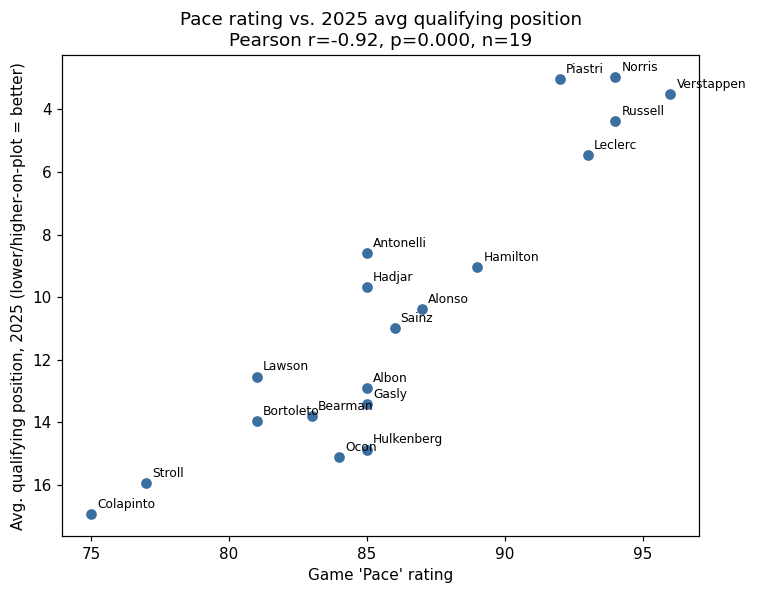

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(merged_2025["pace"], merged_2025["avg_quali_position"], color="#3b6fa0")
for _, row in merged_2025.iterrows():
    ax.annotate(row["driver"].split(" ")[-1], (row["pace"], row["avg_quali_position"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.invert_yaxis()
r, p = stats.pearsonr(merged_2025["pace"], merged_2025["avg_quali_position"])
ax.set_xlabel("Game 'Pace' rating")
ax.set_ylabel("Avg. qualifying position, 2025 (lower/higher-on-plot = better)")
ax.set_title(f"Pace rating vs. 2025 avg qualifying position\nPearson r={r:.2f}, p={p:.3f}, n={len(merged_2025)}")
fig.tight_layout()
fig.savefig("pace_vs_qualifying_2025.png", dpi=130)
plt.show()

## Question 2 — Does "Racecraft" track positions gained during races, specifically?

`positions_gained = grid position - finish position` (positive means the driver moved forward
during the race). This is a much more race-specific metric than points, since points are mostly
determined by *where you started* (i.e., by the car). Gaining places relative to your own grid
slot is closer to an overtaking/racecraft skill signal.

**Important mechanical confound**: a driver who qualifies on pole has *zero* room to gain
positions (there's nobody ahead to pass) and a lot of room to lose them, while a driver starting
16th has a lot of room to gain and comparatively less to lose. So average positions gained is
partly just a function of average starting grid position, not of skill. We check for, and then
adjust for, that confound below.

In [5]:
def positions_gained_correlations(df):
    rows = []
    for attr in ATTRS:
        r, p = stats.pearsonr(df[attr], df["avg_positions_gained"])
        rows.append({"attribute": attr, "r_vs_avg_positions_gained": r, "p": p})
    return pd.DataFrame(rows)


print("2025 (raw, unadjusted for grid slot):")
display(positions_gained_correlations(merged_2025).round(3))

print("\n2026 partial season (raw, unadjusted for grid slot):")
display(positions_gained_correlations(merged_2026).round(3))

r_confound, p_confound = stats.pearsonr(merged_2025["avg_grid"], merged_2025["avg_positions_gained"])
print(f"\nConfound check, 2025: corr(avg grid position, avg positions gained) = "
      f"r={r_confound:.3f}, p={p_confound:.3f}")

2025 (raw, unadjusted for grid slot):


,attribute,r_vs_avg_positions_gained,p
0,overall,-0.322,0.178
1,experience,0.067,0.787
2,racecraft,-0.163,0.506
3,awareness,-0.161,0.511
4,pace,-0.389,0.100



2026 partial season (raw, unadjusted for grid slot):


,attribute,r_vs_avg_positions_gained,p
0,overall,-0.468,0.028
1,experience,0.105,0.641
2,racecraft,-0.439,0.041
3,awareness,-0.266,0.231
4,pace,-0.565,0.006



Confound check, 2025: corr(avg grid position, avg positions gained) = r=0.575, p=0.010


As expected, `avg_positions_gained` is itself significantly correlated with average
starting grid position (drivers who start further back gain more places, mechanically). None of
the raw sub-attribute correlations against `avg_positions_gained` reach significance in 2025, and
`pace` (not `racecraft`) has the strongest raw correlation — but that's likely just because `pace`
also correlates with *not* starting near the back, which mechanically suppresses gains.

To separate "gains more than their grid slot would predict" from "gains more because they
started further back," regress `avg_positions_gained` on `avg_grid` and take the residual —
positions gained *above what average grid position alone predicts*.

In [6]:
def gained_residuals(df):
    slope, intercept, r, p, se = stats.linregress(df["avg_grid"], df["avg_positions_gained"])
    resid = df["avg_positions_gained"] - (slope * df["avg_grid"] + intercept)
    return resid


merged_2025["gained_residual"] = gained_residuals(merged_2025)
merged_2026["gained_residual"] = gained_residuals(merged_2026)


def residual_correlations(df, season_label):
    rows = []
    for attr in ATTRS:
        r, p = stats.pearsonr(df[attr], df["gained_residual"])
        rows.append({"season": season_label, "attribute": attr, "r_vs_gained_residual": r, "p": p})
    return pd.DataFrame(rows)


resid_table = pd.concat([
    residual_correlations(merged_2025, "2025 (full season)"),
    residual_correlations(merged_2026, "2026 (partial, 9 rounds)"),
], ignore_index=True)
resid_table.round(3)

,season,attribute,r_vs_gained_residual,p
0,2025 (full season),overall,0.205,0.401
1,2025 (full season),experience,0.200,0.411
2,2025 (full season),racecraft,0.335,0.161
3,2025 (full season),awareness,0.181,0.459
4,2025 (full season),pace,0.165,0.499
5,"2026 (partial, 9 rounds)",overall,-0.234,0.295
6,"2026 (partial, 9 rounds)",experience,-0.040,0.859
7,"2026 (partial, 9 rounds)",racecraft,-0.141,0.531
8,"2026 (partial, 9 rounds)",awareness,-0.148,0.512
9,"2026 (partial, 9 rounds)",pace,-0.279,0.209


In the **2025 full season**, once the grid-position confound is removed, `racecraft`
has the **strongest** correlation with grid-adjusted positions gained of any sub-attribute
(r ≈ +0.33), ahead of `pace` (r ≈ +0.17) and `overall` (r ≈ +0.20) — directionally consistent
with the idea that "Racecraft" is meant to capture in-race overtaking skill distinct from raw
speed. **But at n=19, p ≈ 0.16 — this does not clear conventional significance, and should be
read as a directional hint, not a finding.**

The **2026 partial season (9 rounds) does not reproduce this pattern** — correlations are weak
and, for `racecraft`, even flip sign. This is exactly the kind of instability you'd expect from
a 9-round sample of a fairly noisy, mechanically confounded metric (safety cars, retirements,
and grid penalties inject a lot of race-to-race variance into positions gained), and it's a
useful caution against reading too much into the 2025 result even though it's directionally
sensible.

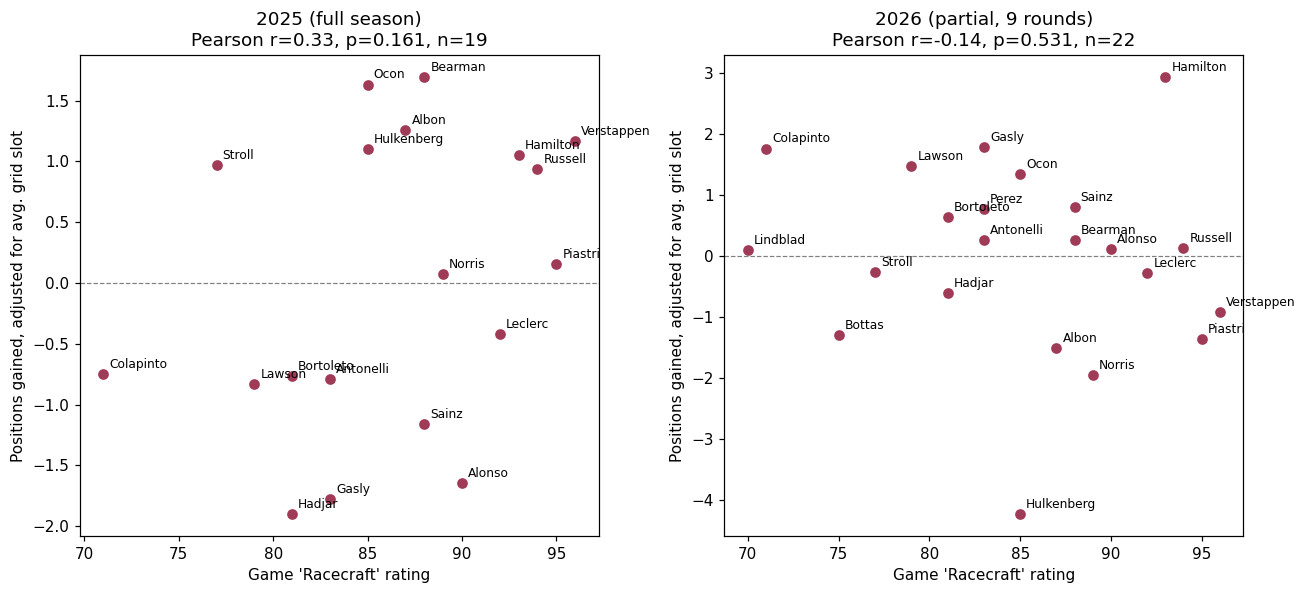

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, df, label in zip(axes, [merged_2025, merged_2026], ["2025 (full season)", "2026 (partial, 9 rounds)"]):
    ax.scatter(df["racecraft"], df["gained_residual"], color="#a03b57")
    for _, row in df.iterrows():
        ax.annotate(row["driver"].split(" ")[-1], (row["racecraft"], row["gained_residual"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    r, p = stats.pearsonr(df["racecraft"], df["gained_residual"])
    ax.set_xlabel("Game 'Racecraft' rating")
    ax.set_ylabel("Positions gained, adjusted for avg. grid slot")
    ax.set_title(f"{label}\nPearson r={r:.2f}, p={p:.3f}, n={len(df)}")

fig.tight_layout()
fig.savefig("racecraft_vs_positions_gained.png", dpi=130)
plt.show()

## Takeaways and honest limitations

- **Pace tracks qualifying performance more tightly than it tracks race scoring** in the
  complete 2025 season (r ≈ -0.92 vs qualifying position vs. r ≈ +0.86 vs points/race) —
  directionally supporting the idea that the game's "Pace" attribute is closer to raw one-lap
  speed than to race-day results, though the two are highly collinear in practice (fast
  qualifiers also tend to score well) so this isn't a clean natural experiment.
- **Racecraft's edge over Pace on grid-adjusted positions gained is directionally present but
  not statistically solid.** In the full 2025 season, Racecraft has the highest correlation with
  positions gained after removing the mechanical grid-slot confound, matching the attribute's
  name and intent — but at n=19 (p≈0.16) it is not significant, and the pattern doesn't hold up
  in the smaller, noisier 9-round 2026 sample. Treat this as "consistent with the intended
  design of the attribute," not as proof the game measures racecraft well.
- **All sub-attributes are highly inter-correlated** in this hand-compiled rating set (a driver
  rated well tends to be rated well on every axis), which structurally limits how much any single
  comparison here can truly isolate one skill from another — the same caveat notebook 01 raised
  about the sub-attribute breakdown applies here.
- **Sample size remains small** (19–22 drivers, one full + one partial season). No result in this
  notebook should be treated as more than a suggestive, descriptive pattern.
- **Positions gained is a noisy, confounded metric** even after the grid-slot adjustment — it
  doesn't account for safety cars, grid penalties, mechanical retirements, or team orders, all of
  which move a driver's finish position for reasons unrelated to skill. A finer-grained
  lap-by-lap overtakes count (e.g., via FastF1 lap data) would be a sturdier version of this
  metric than the classification-based positions-gained used here, but that's out of scope for
  this notebook.